<a href="https://colab.research.google.com/github/voleneva/MMO/blob/main/%D0%9E%D0%BB%D0%B5%D0%BD%D0%B5%D0%B2%D0%B0_%D0%92_%D0%92_%D0%A0%D0%9A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оленева Валентина Васильена ИУ5-25МВ

Задача №5.

Для набора данных проведите кодирование одного (произвольного) категориального признака с использованием метода "one-hot encoding".

Первые 5 строк данных:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_

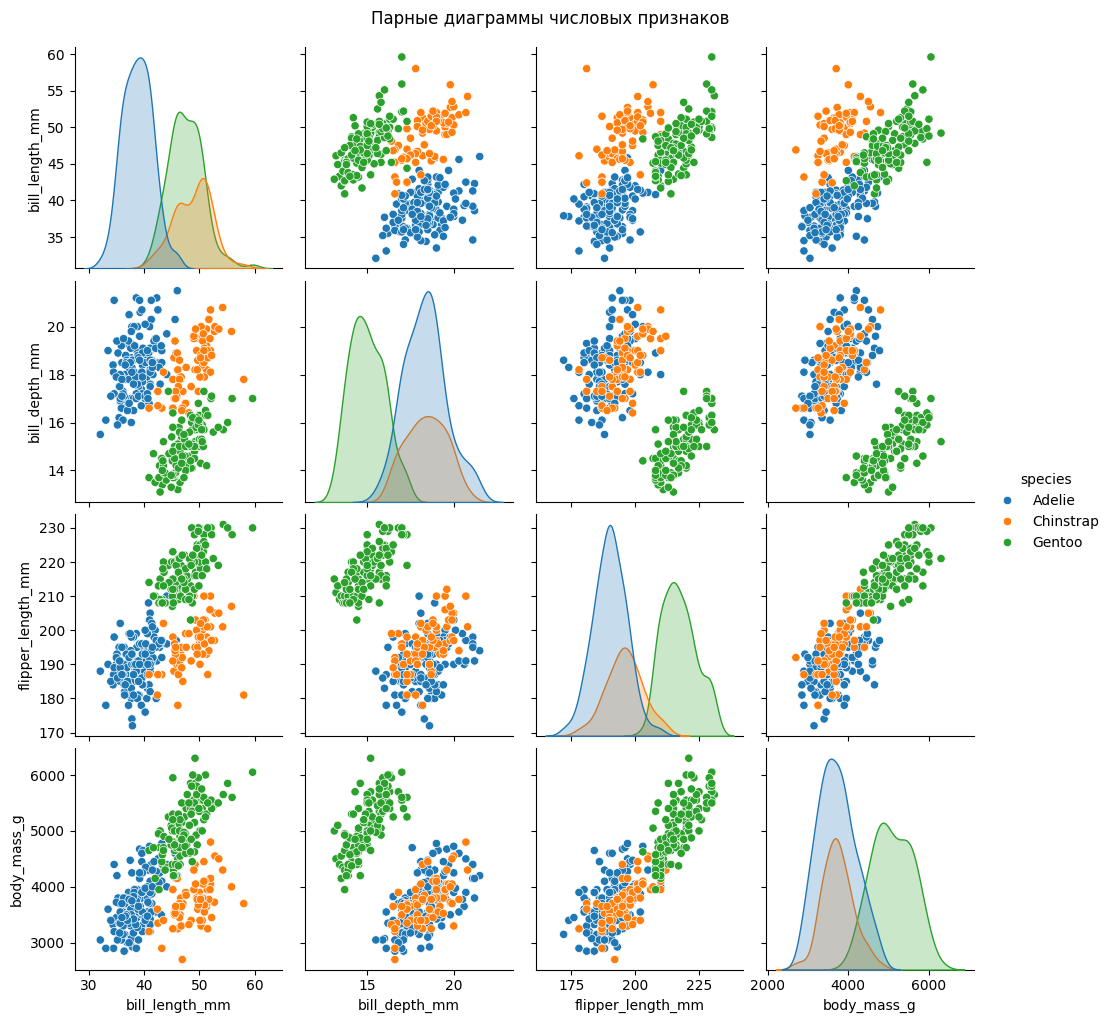


Выбран категориальный признак: 'island'
Уникальные значения: ['Torgersen' 'Biscoe' 'Dream']

Результат one-hot encoding:
Добавлены столбцы: ['island_Biscoe', 'island_Dream', 'island_Torgersen']

Первые 5 строк после кодирования:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  island_Biscoe  island_Dream  island_Torgersen  
0       3750.0    Male          False         False              True  
1       3800.0  Female          False         False              True  
2       3250.0  Female          False         False              True  
4       3450.0  Female          False

In [1]:
# ================================
# 1. Установка и импорт библиотек
# ================================
!pip install seaborn matplotlib pandas --quiet

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ================================
# 2. Загрузка набора данных
# ================================
# Используем встроенный датасет penguins
df = sns.load_dataset('penguins')
print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())

# ================================
# 3. Предварительная обработка (удаление пропусков)
# ================================
# Для pairplot и one-hot encoding избавимся от строк с NaN
df_clean = df.dropna()
print(f"\nРазмер после удаления пропусков: {df_clean.shape}")

# ================================
# 4. Построение парных диаграмм (pairplot)
# ================================
# Выбираем числовые колонки для pairplot
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nЧисловые признаки для pairplot: {numerical_cols}")

# Строим парные диаграммы с цветовой дифференциацией по виду пингвина (опционально)
sns.pairplot(df_clean, vars=numerical_cols, hue='species', diag_kind='kde')
plt.suptitle('Парные диаграммы числовых признаков', y=1.02)
plt.show()

# ================================
# 5. One-hot encoding для категориального признака
# ================================
# Выбираем произвольный категориальный признак – 'island' (остров обитания)
categorical_feature = 'island'
print(f"\nВыбран категориальный признак: '{categorical_feature}'")
print("Уникальные значения:", df_clean[categorical_feature].unique())

# Применяем one-hot encoding с помощью pandas get_dummies
one_hot_encoded = pd.get_dummies(df_clean[categorical_feature], prefix=categorical_feature)

# Добавляем закодированные столбцы к исходному DataFrame
df_final = pd.concat([df_clean, one_hot_encoded], axis=1)

# Можно удалить исходный категориальный столбец (по желанию)
# df_final.drop(categorical_feature, axis=1, inplace=True)

print("\nРезультат one-hot encoding:")
print(f"Добавлены столбцы: {one_hot_encoded.columns.tolist()}")
print("\nПервые 5 строк после кодирования:")
print(df_final.head())

# ================================
# 6. Проверка (демонстрация изменений)
# ================================
print("\nИтоговая размерность DataFrame:", df_final.shape)
print("Типы данных после one-hot encoding:")
print(df_final.dtypes)

Задача №23.

Для набора данных для одного (произвольного) числового признака проведите обнаружение и удаление выбросов на основе правила трех сигм.

Исходный размер (без пропусков): (333, 7)
Числовые признаки: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


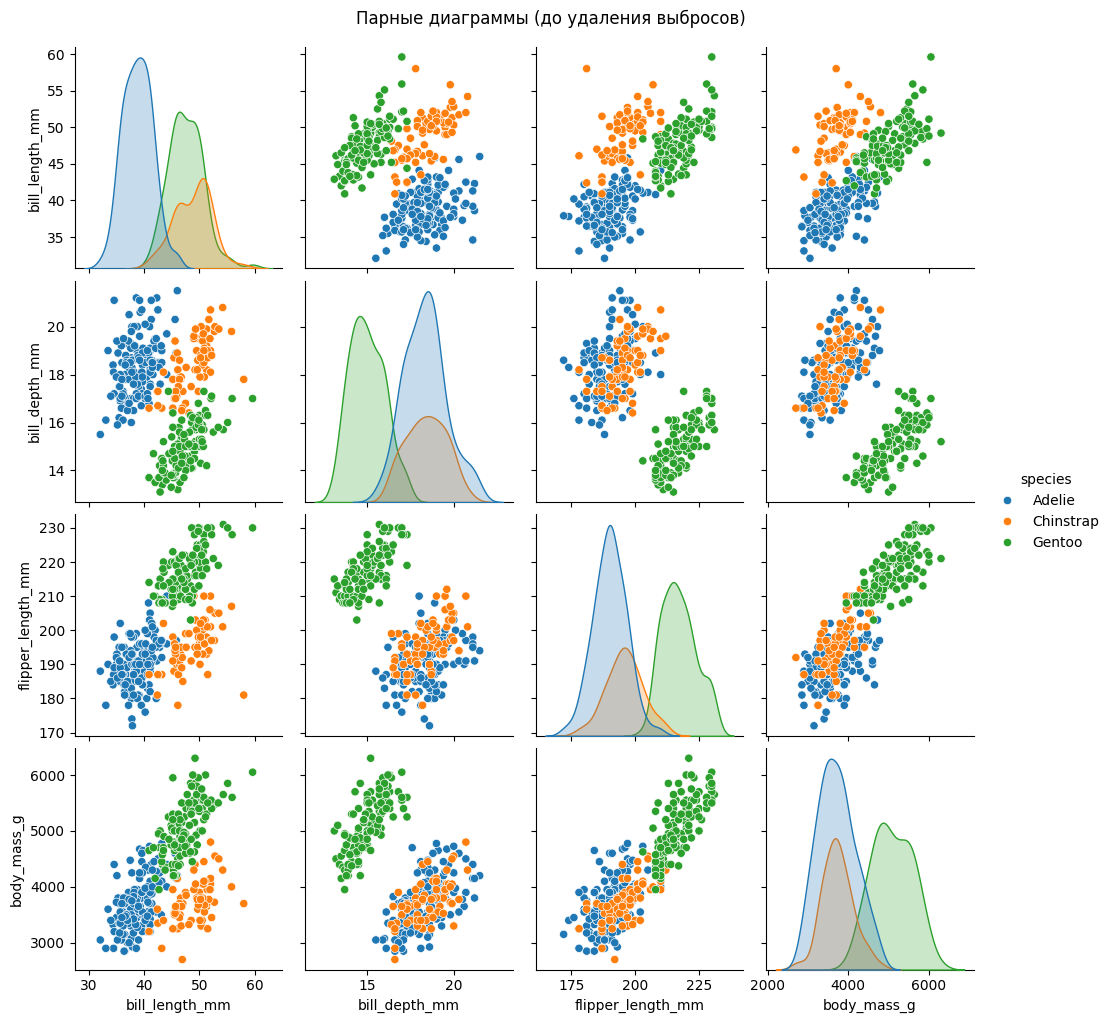


Признак 'body_mass_g':
  Среднее = 4207.06, σ = 805.22
  Границы 3σ: [1791.41, 6622.70]
  Количество выбросов: 0
  Выбросов не обнаружено (данные уже хорошо распределены)

Размер после удаления выбросов: (333, 7)
Удалено записей: 0


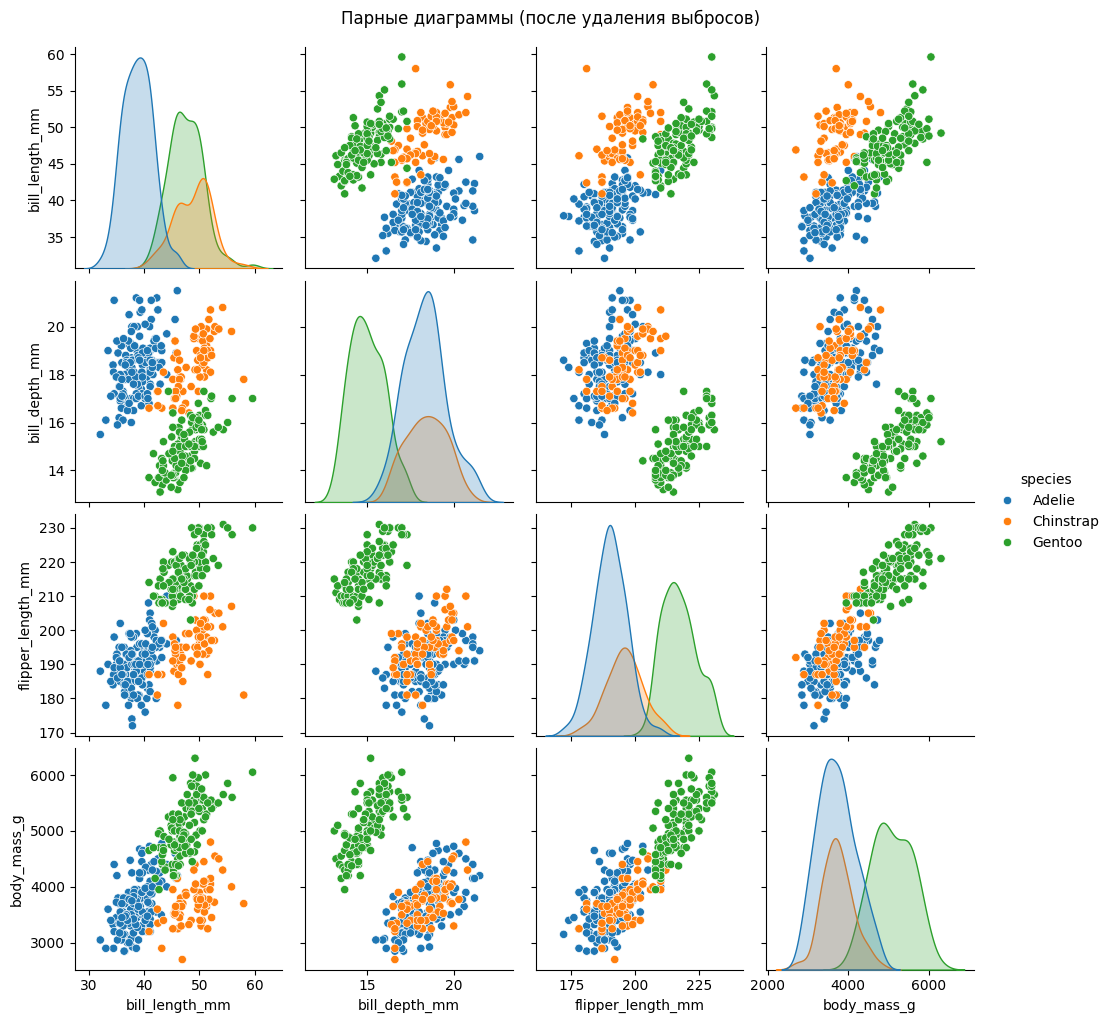

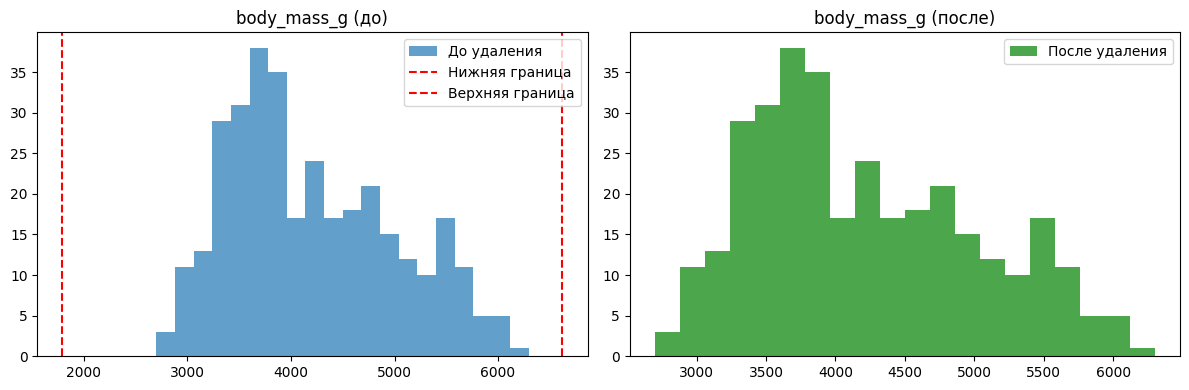

In [2]:
# ================================
# 1. Импорт библиотек
# ================================
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 2. Загрузка данных (отличается от лекции)
# ================================
df = sns.load_dataset('penguins')
df_clean = df.dropna().copy()
print("Исходный размер (без пропусков):", df_clean.shape)

# ================================
# 3. Парные диаграммы ДО удаления выбросов
# ================================
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые признаки:", numerical_cols)

sns.pairplot(df_clean, vars=numerical_cols, hue='species', diag_kind='kde')
plt.suptitle('Парные диаграммы (до удаления выбросов)', y=1.02)
plt.show()

# ================================
# 4. Выбор числового признака и удаление выбросов по 3σ
# ================================
feature = 'body_mass_g'   # можно заменить на любой числовой
data = df_clean[feature]

mean = data.mean()
std = data.std()
lower = mean - 3*std
upper = mean + 3*std

print(f"\nПризнак '{feature}':")
print(f"  Среднее = {mean:.2f}, σ = {std:.2f}")
print(f"  Границы 3σ: [{lower:.2f}, {upper:.2f}]")

outliers = data[(data < lower) | (data > upper)]
print(f"  Количество выбросов: {len(outliers)}")
if len(outliers) > 0:
    print(f"  Выбросы: {outliers.tolist()}")
else:
    print("  Выбросов не обнаружено (данные уже хорошо распределены)")

# Удаляем выбросы
df_filtered = df_clean[(df_clean[feature] >= lower) & (df_clean[feature] <= upper)]
print(f"\nРазмер после удаления выбросов: {df_filtered.shape}")
print(f"Удалено записей: {df_clean.shape[0] - df_filtered.shape[0]}")

# ================================
# 5. Парные диаграммы ПОСЛЕ удаления выбросов
# ================================
sns.pairplot(df_filtered, vars=numerical_cols, hue='species', diag_kind='kde')
plt.suptitle('Парные диаграммы (после удаления выбросов)', y=1.02)
plt.show()

# ================================
# 6. Дополнительная проверка (сравнение распределения)
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean[feature], bins=20, alpha=0.7, label='До удаления')
axes[0].axvline(lower, color='r', linestyle='--', label='Нижняя граница')
axes[0].axvline(upper, color='r', linestyle='--', label='Верхняя граница')
axes[0].set_title(f'{feature} (до)')
axes[0].legend()

axes[1].hist(df_filtered[feature], bins=20, alpha=0.7, color='green', label='После удаления')
axes[1].set_title(f'{feature} (после)')
axes[1].legend()
plt.tight_layout()
plt.show()